## A1.6 Regresión no lineal

***

**1.** Se importan los datos del archivo *Tiempo de entrega*

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("Tiempo de Entrega.csv")

Se detectan celdas con valores no numéricos, negativos, muy grandes, o con un valor de cero; por lo que se decide imputar dichos valores.

Para esto se convierten las columnas a tipo numérico, así como los ceros se reemplazan por *nan*. 

Se calcula la media de *Tiempo* y la moda de *Calificacion*, parámetros seleccionados para reemplazar los valores de los datos no válidos/raros.

Con esto se imputan los valores y se guarda el dataset ya limpio.

In [6]:
data["Tiempo"] = pd.to_numeric(data["Tiempo"], errors="coerce")
data["Calificacion"] = pd.to_numeric(data["Calificacion"], errors="coerce")
data.replace(0, np.nan, inplace=True)

prom_tiempo = data["Tiempo"].mean()
moda_calificacion = data["Calificacion"].mode()[0] 

# Imputar valores faltantes
data_mod=data.copy()
data_mod["Tiempo"]=data_mod["Tiempo"].fillna(prom_tiempo)
data_mod["Calificacion"]=data_mod["Calificacion"].fillna(moda_calificacion)
data_mod.loc[data_mod["Tiempo"]>350,"Tiempo"]=prom_tiempo
data_mod.loc[data_mod["Tiempo"]<0,"Tiempo"]=prom_tiempo

data_mod.to_csv("Tiempo_de_entrega_corregido.csv", index=False)

Se genera una gráfica de dispersión que muestra el comportamiento de los datos.

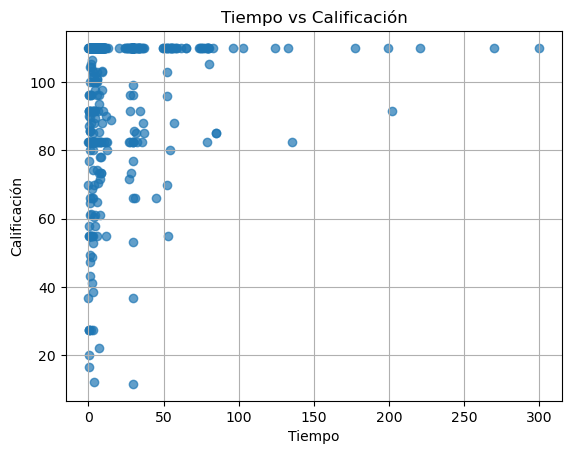

In [8]:
plt.scatter(data_mod["Tiempo"], data_mod["Calificacion"], alpha=0.7)
plt.xlabel("Tiempo")
plt.ylabel("Calificación")
plt.title("Tiempo vs Calificación")
plt.grid(True)
plt.show()

Considero que posiblemente una regresión de segundo grado podría ser adecuada, aunque con un alto valor de error.

***

**2.** Para separar los datos en entrenamiento y prueba con una relación 70/30 se importa *train_test_split*. Además se calculan los promedios de ambas variables para el conjunto de entrenamiento y el de prueba.

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(data_mod.Tiempo,data_mod.Calificacion,train_size=0.7,random_state=42)

prom_tiempo_train=X_train.mean()
prom_tiempo_test=X_test.mean()

prom_calificacion_train=Y_train.mean()
prom_calificacion_test=Y_test.mean()

print('Promedio de tiempo en entrenamiento:',prom_tiempo_train)
print('Promedio de tiempo en prueba:',prom_tiempo_test)
print('Promedio de calificación en entrenamiento:',prom_calificacion_train)
print('Promedio de calificación en prueba:',prom_calificacion_test)

Promedio de tiempo en entrenamiento: 20.206924779968034
Promedio de tiempo en prueba: 16.1601128298234
Promedio de calificación en entrenamiento: 96.32506535483873
Promedio de calificación en prueba: 98.69051218045114


En este caso, los valores promedio entre el conjunto de entrenamiento y el conjunto de prueba de cada una de las variables son bastante similares. Esto significa que la división fue balanceada y que el modelo que se entrene podrá generalizar bien a nuevos datos. 

***

**3.** Se importa *PolynomialFeatures* y la librería *statsmodels.api*. Luego, se entrena un modelo de regresión polinomial de segundo grado utilizando los datos de entrenamiento. Posterior a esto se imprime un resumen de los resultados obtenidos, así como una gráfica de disppersión.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     4.078
Date:                Wed, 12 Feb 2025   Prob (F-statistic):             0.0179
Time:                        17:33:38   Log-Likelihood:                -1382.8
No. Observations:                 310   AIC:                             2772.
Df Residuals:                     307   BIC:                             2783.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
0             93.7508      1.548     60.574      0.0

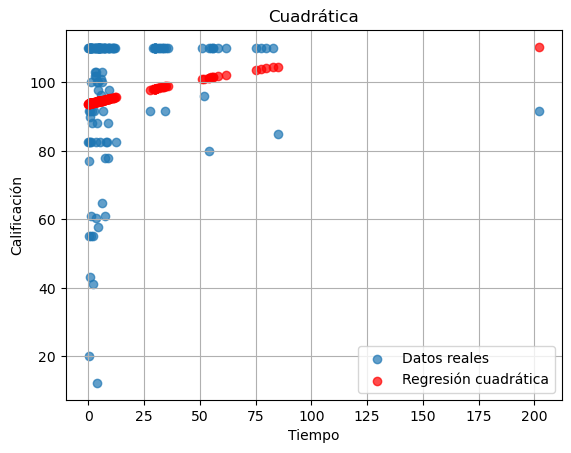

In [16]:
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm

Xtemp_train=X_train.array.reshape(-1,1)
Xtemp_test=X_test.array.reshape(-1,1)
polyq_train=PolynomialFeatures(degree=2).fit(Xtemp_train)
polyq_test=PolynomialFeatures(degree=2).fit(Xtemp_test)
Xq_train=pd.DataFrame(polyq_train.transform(Xtemp_train))
Xq_test=pd.DataFrame(polyq_test.transform(Xtemp_test))
mq=sm.OLS(list(Y_train),Xq_train).fit()
print(mq.summary())

plt.scatter(X_test,Y_test,alpha=0.7,label="Datos reales")
plt.scatter(X_test,mq.predict(Xq_test),color="red",alpha=0.7,label="Regresión cuadrática")
plt.xlabel("Tiempo")
plt.ylabel("Calificación")
plt.title("Cuadrática")
plt.legend()
plt.grid(True)
plt.show()

El modelo cuadrático no parece ser una buena opción, ya que el término cuadrático no es significativo. Dado el bajo valor de la R^2, el modelo tiene poca capacidad predictiva y no explica bien la variabilidad en los datos.
Sería recomendable explorar otros métodos que puedan mejorar la predicción.

***

**4.** Se importa la *PiecewiseRegressor* para entrenar un modelo de regresión segmentada. Se ajusta el modelo usando los datos de entrenamiento, incluyendo el término cuadrático, para así crear regresiones cuadráticas en cada segmento. Después de esto, se grafican los datos obtenidos.

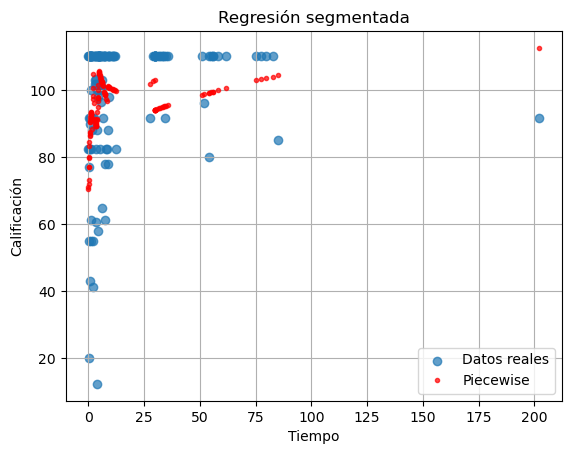

In [20]:
from mlinsights.mlmodel import PiecewiseRegressor

ms=PiecewiseRegressor('bins').fit(Xq_train.iloc[:,1:],Y_train)
yHat_ms=ms.predict(Xq_test.iloc[:,1:])

plt.scatter(X_test,Y_test,alpha=0.7,label="Datos reales")
plt.plot(X_test,yHat_ms,"r.",alpha=0.7,label="Piecewise")
plt.xlabel("Tiempo")
plt.ylabel("Calificación")
plt.title("Regresión segmentada")
plt.legend()
plt.grid(True)
plt.show()

***

**5.** Se importa *KNeighborsRegressor* para entrenar un modelo KNN para regresión utilizando el valor k=3. En este caso también se genera una gráfica de dispersión para mejor visualización de los datos.

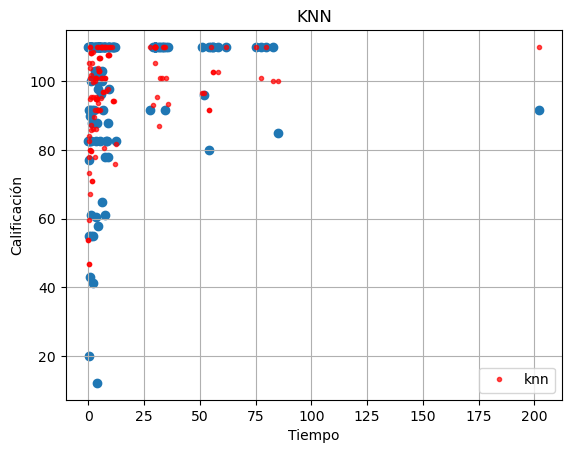

In [23]:
from sklearn.neighbors import KNeighborsRegressor as KNN
k=3
mk=KNN(k).fit(Xtemp_train,Y_train)
yHat_mk=mk.predict(Xtemp_test)

plt.scatter(X_test,Y_test)
plt.plot(X_test,yHat_mk,"r.",alpha=0.7,label="knn")
plt.xlabel("Tiempo")
plt.ylabel("Calificación")
plt.title("KNN")
plt.legend()
plt.grid(True)
plt.show()

***

**6.** Se calcula el RSE en los datos de prueba para los 3 modelos.

In [26]:
RSS_ols = sum((list(Y_test) - mq.predict(Xq_test)) ** 2)
RSE_ols = np.sqrt(RSS_ols / (len(Y_test) - 1))
print('RSE de Regresión Cuadrática (OLS):', RSE_ols)

RSS_ms=sum((list(Y_test)-yHat_ms)**2)
RSE_ms=np.sqrt(RSS_ms/(len(Y_test)-1))
print('RSE de Regresión Segmentada (Piecewise):', RSE_ms)

RSS_mk=sum((list(Y_test)-yHat_mk)**2)
RSE_mk=np.sqrt(RSS_mk/(len(Y_test)-1))
print('RSE de KNN:', RSE_mk)

RSE de Regresión Cuadrática (OLS): 18.9533772854604
RSE de Regresión Segmentada (Piecewise): 18.802087270617058
RSE de KNN: 20.66055164416792


En este caso el modelo con menor RSE es el de regresión segmentada. Por lo que se podría decir que es el que mejor ajusta los datos en términos de error. Sin embargo, también es importante considerar la interpretabilidad del modelo.

- Piecewise: se adapta bien a estructuras de datos con segmentos diferenciados, pero puede ser menos interpretable que otros modelos.
- Regresión cuadrática: es un modelo simple y fácil de interpretar, pero no captura bien relaciones complejas.
- KNN: no asume una forma específica de la relación entre variables, lo que le permite capturar relaciones no lineales, pero puede ser más sensible a los valores atípicos y el número de vecinos elegido afecta el resultado.

***

**7.** Por último, se gráfica tantos las calificaciones reales como las predicciones por los 3 modelos.

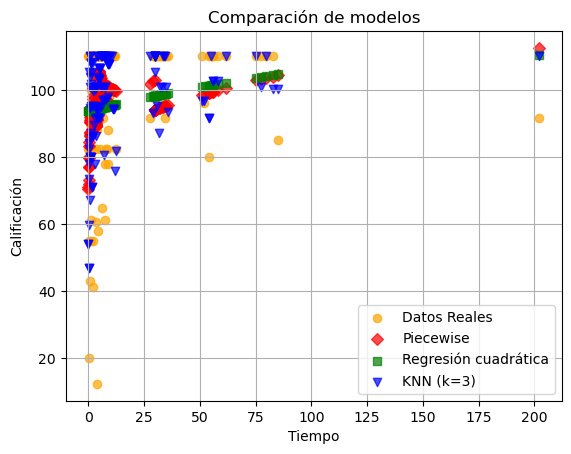

In [30]:
plt.scatter(X_test,Y_test,alpha=0.7,marker="o",label="Datos Reales",color="orange")
plt.scatter(X_test,yHat_ms,alpha=0.7,color="red",marker="D",label="Piecewise")
plt.scatter(X_test,mq.predict(Xq_test),alpha=0.7,color="green",marker="s",label="Regresión cuadrática")
plt.scatter(X_test,yHat_mk,alpha=0.7,color="blue",marker="v",label=f"KNN (k={k})")

plt.xlabel("Tiempo")
plt.ylabel("Calificación")
plt.title("Comparación de modelos")
plt.legend()
plt.grid(True)
plt.show()